# <center> VAI Store - Modelo Preditivo </center>

---

Com base no dataset que preparamos na etapa de Engenharia de Variáveis, nosso objetivo neste notebook é construir um modelo de machine learning para prever a demanda diária de produtos (QTD_TOTAL).

Seguindo o desafio do case, vamos focar em criar um modelo único e escalável, capaz de aprender os padrões de todos os produtos e filiais simultaneamente. Para isso, usaremos um modelo de *Gradient Boosting* (LightGBM) e avaliaremos sua "acurácia" usando métricas de regressão (como RMSE e MAE) em um conjunto de validação temporal.

### **1. Imports e Carregamento de Dados**

Visão Geral: Vamos começar importando as bibliotecas necessárias para a modelagem: pandas para os dados, lightgbm para o modelo e sklearn.metrics para avaliar a performance. Em seguida, carregaremos o feature_engineered_dataset.parquet. Este arquivo, por ser Parquet, será lido rapidamente e já conterá todos os tipos de dados otimizados que definimos.

In [27]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import warnings

warnings.filterwarnings('ignore')

# Define os caminhos (subindo um nível)
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed')
DATA_FILE = os.path.join(PROCESSED_DATA_PATH, 'feature_engineered_dataset.parquet')

print(f"Carregando dataset de: {os.path.abspath(DATA_FILE)}")

# Carrega o dataset
df = pd.read_parquet(DATA_FILE)

# Garante que a data esteja no formato correto (o Parquet preserva isso)
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'])

print("Dataset carregado com sucesso.")
df.info()

Carregando dataset de: c:\Users\felip\OneDrive\Documentos\GitHub\Grupo6-ProjetoFinal\data\processed\feature_engineered_dataset.parquet
Dataset carregado com sucesso.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4911440 entries, 0 to 4911439
Data columns (total 62 columns):
 #   Column                             Dtype         
---  ------                             -----         
 0   SKU                                Int64         
 1   SHOPPING                           int8          
 2   DATA_ATEND                         datetime64[ns]
 3   QTD_TOTAL                          float32       
 4   FATUR_TOTAL                        float32       
 5   CLIENTES_UNICOS                    float32       
 6   CATEGORIA                          object        
 7   SUBCATEGORIA                       object        
 8   DIA_SEMANA                         int8          
 9   DIA_DO_MES                         int8          
 10  DIA_DO_ANO                         int16         
 11  M

### **2. Preparação de Features e Alvo**

Visão Geral: Agora, precisamos preparar os dados para o modelo. Vamos separar o nosso alvo (o que queremos prever) das nossas features (o que usamos para prever).

* Alvo (y): QTD_TOTAL.

* Features (X): Todas as 58 colunas restantes que dão contexto ao modelo.

Vamos também converter as colunas de texto (como CATEGORIA) e colunas numéricas que representam categorias (como DIA_SEMANA) para o dtype especial 'category'. Isso é uma otimização crucial para o LightGBM, pois permite que ele lide com elas nativamente, sem a necessidade de One-Hot Encoding.

In [28]:
print("Preparando features e alvo...")

# 1. Definir o alvo
TARGET = 'QTD_TOTAL'

# 2. Definir colunas categóricas
categorical_features = [
    'SKU',
    'SHOPPING',
    'CATEGORIA',
    'SUBCATEGORIA',
    'DIA_SEMANA',
    'DIA_DO_MES',
    'DIA_DO_ANO',
    'MES',
    'SEMANA_DO_ANO',
    'ANO',
    'INICIO_MES',
    'FIM_MES',
    'ANTECIPACAO_PASCOA_14D',
    'ANTECIPACAO_NATAL_21D',     
    'ANTECIPACAO_ANO_NOVO_7D',    
    'EH_FERIADO',
    'EM_PROMOCAO'
]

# 3. Converter colunas categóricas para o dtype 'category'
for col in categorical_features:
    df[col] = df[col].astype('category')

# 4. Definir a lista final de features (X)
features_to_drop = [
    TARGET, 
    'DATA_ATEND',
    'FATUR_TOTAL', 
    'CLIENTES_UNICOS'
]

for col in df.columns:
    if col.startswith(('FATUR_TOTAL_', 'CLIENTES_UNICOS_')):
        features_to_drop.append(col)

# A feature 'ANTECIPACAO_NATAL_14D' (antiga) será dropada automaticamente
# pois não está no df e não está na lista de features
features = [col for col in df.columns if col not in features_to_drop]

print(f"Total de features para o modelo: {len(features)}")
print(f"Alvo: {TARGET}")

# Verifica os dtypes finais
df[features].info()

Preparando features e alvo...
Total de features para o modelo: 32
Alvo: QTD_TOTAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4911440 entries, 0 to 4911439
Data columns (total 32 columns):
 #   Column                       Dtype   
---  ------                       -----   
 0   SKU                          category
 1   SHOPPING                     category
 2   CATEGORIA                    category
 3   SUBCATEGORIA                 category
 4   DIA_SEMANA                   category
 5   DIA_DO_MES                   category
 6   DIA_DO_ANO                   category
 7   MES                          category
 8   SEMANA_DO_ANO                category
 9   ANO                          category
 10  INICIO_MES                   category
 11  FIM_MES                      category
 12  ANTECIPACAO_PASCOA_14D       category
 13  ANTECIPACAO_NATAL_21D        category
 14  ANTECIPACAO_ANO_NOVO_7D      category
 15  EH_FERIADO                   category
 16  PRECO_MEDIO_DIA           

### **3. Divisão de Dados (Train/Validation Split)**

Visão Geral: Este é o passo mais crítico da modelagem. Vamos separar o último mês de dados para ser nosso "conjunto de validação" (o futuro que o modelo nunca viu). Todo o resto será usado para "treino".

In [29]:
# Define a data de corte (vamos usar o último mês como validação)
data_maxima = df['DATA_ATEND'].max()
data_corte = data_maxima - pd.DateOffset(months=1)

# Divide o DataFrame
df_train = df[df['DATA_ATEND'] < data_corte]
df_val = df[df['DATA_ATEND'] >= data_corte]

# Separa X (features) e y (alvo)
X_train = df_train[features]
y_train = df_train[TARGET]

X_val = df_val[features]
y_val = df_val[TARGET]

print(f"Período de Treino: {df_train['DATA_ATEND'].min().date()} até {df_train['DATA_ATEND'].max().date()}")
print(f"Período de Validação: {df_val['DATA_ATEND'].min().date()} até {df_val['DATA_ATEND'].max().date()}")
print(f"Tamanho do Treino: {len(X_train)} linhas")
print(f"Tamanho da Validação: {len(X_val)} linhas")

Período de Treino: 2024-01-02 até 2024-11-29
Período de Validação: 2024-11-30 até 2024-12-31
Tamanho do Treino: 4480848 linhas
Tamanho da Validação: 430592 linhas


### **4. Treinamento do Modelo LightGBM**

Visão Geral: Agora, vamos treinar nosso modelo LGBMRegressor. Definimos alguns "hiperparâmetros" básicos. O mais importante é o eval_set, onde passamos nosso conjunto de validação. Isso permite que o modelo nos diga, a cada 100 "árvores" (log_evaluation), qual é o seu RMSE no conjunto de validação. O early_stopping faz o modelo parar de treinar automaticamente se a performance não melhorar, evitando overfitting.

In [30]:
print("Iniciando o treinamento do modelo LightGBM (v2 - Tunado)...")

# Define os parâmetros do LGBM (mais complexos)
params = {
    'objective': 'regression_l1', 
    'metric': 'rmse',             
    'n_estimators': 2000,         
    'learning_rate': 0.02,        
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'num_leaves': 128,              
    'verbose': -1,
    'n_jobs': -1,                 
    'seed': 42,
    'boosting_type': 'gbdt',
}

# Inicializa o modelo
model = lgb.LGBMRegressor(**params)

# Treina o modelo
model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[
        lgb.log_evaluation(period=100), 
        lgb.early_stopping(stopping_rounds=100) # Aumentamos a paciência
    ]
)

print("Treinamento concluído.")

Iniciando o treinamento do modelo LightGBM (v2 - Tunado)...
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 10.1339
[200]	valid_0's rmse: 6.98626
[300]	valid_0's rmse: 3.71783
[400]	valid_0's rmse: 2.42834
[500]	valid_0's rmse: 2.35651
[600]	valid_0's rmse: 2.32694
[700]	valid_0's rmse: 2.31034
[800]	valid_0's rmse: 2.29642
[900]	valid_0's rmse: 2.29225
[1000]	valid_0's rmse: 2.29235
Early stopping, best iteration is:
[942]	valid_0's rmse: 2.29159
Treinamento concluído.


### **5. Avaliação de Performance (Acurácia)**

Visão Geral: O modelo está treinado. Agora é a hora de responder ao case. Vamos usar o modelo para fazer previsões (predict) no conjunto de validação (dados que ele nunca viu). Em seguida, compararemos essas previsões com os valores reais (y_val) e calcularemos o RMSE e o MAE, que são as nossas métricas de "acurácia" para este problema de regressão.

In [31]:
print("Avaliando a performance do modelo...")

# Faz as previsões no conjunto de validação
y_pred = model.predict(X_val)

# Garante que previsões não sejam negativas (não podemos vender -1 KG)
y_pred[y_pred < 0] = 0

# Calcula o MSE (Mean Squared Error)
mse = mean_squared_error(y_val, y_pred)

# Calcula o RMSE (Root Mean Squared Error) manualmente
rmse = np.sqrt(mse)

# Calcula o MAE
mae = mean_absolute_error(y_val, y_pred)

print("\n--- Métricas de Performance (Acurácia) ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error):    {mae:.4f}")

print(f"\nEm média, o modelo erra a previsão de QTD_TOTAL em {mae:.4f} unidades.")

Avaliando a performance do modelo...

--- Métricas de Performance (Acurácia) ---
RMSE (Root Mean Squared Error): 2.2916
MAE (Mean Absolute Error):    0.2839

Em média, o modelo erra a previsão de QTD_TOTAL em 0.2839 unidades.


### **6. Análise de Erros: Real vs. Previsto**

Visão Geral: Vamos criar um gráfico de dispersão (scatterplot) para comparar o valor real (y_val) com o valor previsto (y_pred). Se o modelo fosse perfeito, todos os pontos estariam em uma linha reta de 45 graus. Vamos ver onde o nosso modelo está falhando (provavelmente em valores altos).

Plotando análise de Real vs. Previsto...


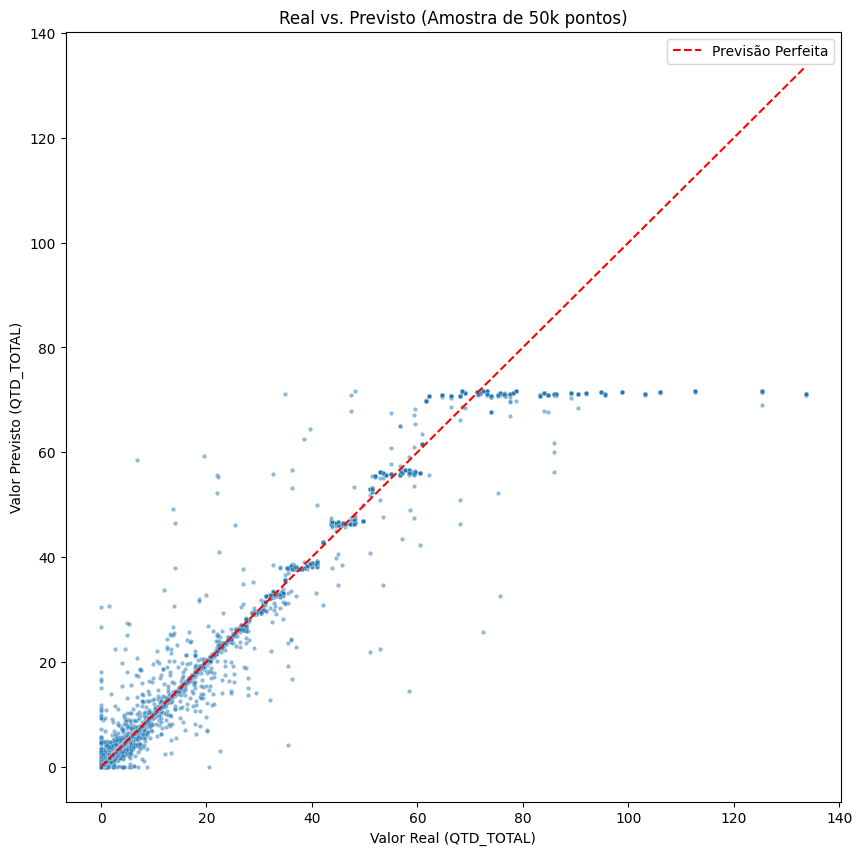

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotando análise de Real vs. Previsto...")

# Cria um DataFrame de resultados para facilitar a plotagem
df_resultados = pd.DataFrame({
    'Real': y_val,
    'Previsto': y_pred
})

# Amostra os dados para o gráfico não ficar muito pesado
# (Plotar 1.4M de pontos é inviável)
df_sample = df_resultados.sample(n=min(50000, len(df_resultados)), random_state=42)

plt.figure(figsize=(10, 10))
sns.scatterplot(
    x='Real', 
    y='Previsto', 
    data=df_sample, 
    alpha=0.5, 
    s=10 # Tamanho do ponto
)
plt.title('Real vs. Previsto (Amostra de 50k pontos)')
plt.xlabel('Valor Real (QTD_TOTAL)')
plt.ylabel('Valor Previsto (QTD_TOTAL)')

# Linha de 45 graus (perfeição)
lim_max = max(df_sample['Real'].max(), df_sample['Previsto'].max())
plt.plot([0, lim_max], [0, lim_max], 'r--', label='Previsão Perfeita')

plt.legend()
plt.show()

### **7. Investigação dos Piores Erros**

Visão Geral: Como o RMSE nos disse que há erros grandes, vamos encontrá-los. Vamos juntar nossas previsões com os dados de validação originais (df_val), calcular o erro para cada linha e, em seguida, mostrar os "10 Piores Erros" (onde o modelo mais subestimou a venda). Isso nos dirá exatamente quais SKUs e datas precisam de mais atenção.

In [33]:
print("Investigando os piores erros do modelo...")

# Junta as previsões de volta ao df_val original
df_val_results = df_val.copy()
df_val_results['Previsto'] = y_pred
df_val_results['Erro_Absoluto'] = (df_val_results['Previsto'] - df_val_results[TARGET]).abs()
df_val_results['Erro'] = (df_val_results['Previsto'] - df_val_results[TARGET])

# Ordena pelos piores erros (onde o modelo mais subestimou)
# Erro = Previsto - Real (Um erro de -50 significa que previmos 5 e o real foi 55)
piores_erros = df_val_results.sort_values(by='Erro', ascending=True)

# Mostra as colunas mais importantes
colunas_display = [
    'DATA_ATEND',
    'SKU',
    'CATEGORIA',
    'QTD_TOTAL',
    'Previsto',
    'Erro',
    'ANTECIPACAO_PASCOA_14D',
    'ANTECIPACAO_NATAL_21D',
    'ANTECIPACAO_ANO_NOVO_7D'
]

print("\n--- 10 Piores Erros (Modelo Subestimou a Venda) ---")
print(piores_erros[colunas_display].head(10))

print("\n--- 10 'Melhores' Erros (Modelo Superestimou a Venda) ---")
print(piores_erros[colunas_display].tail(10))

Investigando os piores erros do modelo...

--- 10 Piores Erros (Modelo Subestimou a Venda) ---
        DATA_ATEND   SKU            CATEGORIA   QTD_TOTAL   Previsto  \
1524012 2024-12-30  1813  Bacalhau & Pescados  112.611000  37.730522   
1524013 2024-12-30  1813  Bacalhau & Pescados  112.611000  42.181328   
1521732 2024-12-10  1813  Bacalhau & Pescados  105.954002  37.933733   
2835622 2024-12-16  6159  Bacalhau & Pescados   77.634003  12.031739   
1522077 2024-12-13  1813  Bacalhau & Pescados  133.600006  68.001283   
1522078 2024-12-13  1813  Bacalhau & Pescados  133.600006  68.001283   
1522079 2024-12-13  1813  Bacalhau & Pescados  133.600006  68.001283   
1522080 2024-12-13  1813  Bacalhau & Pescados  133.600006  68.001283   
1522075 2024-12-13  1813  Bacalhau & Pescados  133.600006  68.001283   
1522076 2024-12-13  1813  Bacalhau & Pescados  133.600006  68.001283   

              Erro ANTECIPACAO_PASCOA_14D ANTECIPACAO_NATAL_21D  \
1524012 -74.880478                      0    